# Project 5.2: Scenario Analysis and Business Insights - 06-13-2026 - Mormoo5363

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "Mormoo5363"

display(Markdown("### Load Dataset and Prepare Optimized Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Load dataset
heart = pd.read_csv("heart_disease_uci.csv")

# Create binary classification target
heart["heart_disease"] = heart["num"].apply(lambda x: 1 if x > 0 else 0)

# Drop non-feature columns
X = heart.drop(["id", "num", "heart_disease"], axis=1)
y = heart["heart_disease"]

# Handle missing values
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optimized SVM from Part 4
optimized_svm = SVC(
    C=10,
    gamma=0.001,
    kernel="rbf",
    probability=True
)

optimized_svm.fit(X_train_scaled, y_train)

# Baseline predictions
baseline_predictions = optimized_svm.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline Accuracy:", baseline_accuracy)
print("Dataset Shape:", heart.shape)
print("Features Used:", X.shape[1])

### Load Dataset and Prepare Optimized Model

Date: 2026-06-13

Student ID: Mormoo5363

C:\Users\Morgan Moore\AppData\Local\Temp\ipykernel_19640\108450635.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "bool"]).columns
e:\AI_ML_Class\tf_env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Baseline Accuracy: 0.8260869565217391
Dataset Shape: (920, 17)
Features Used: 21


## Scenario Development

### Scenario 1: Improved Cardiovascular Health

**Assumptions**

* Cholesterol levels decrease by 15%.
* Resting blood pressure decreases by 10%.
* Maximum heart rate increases by 5%.

**Rationale**
This scenario represents individuals who adopt healthier lifestyles through improved diet, exercise, and preventive healthcare. Lower cholesterol and blood pressure are known to reduce cardiovascular risk and may decrease the likelihood of heart disease according to the model.

---

### Scenario 2: Increased Cardiovascular Risk

**Assumptions**

* Cholesterol levels increase by 15%.
* Resting blood pressure increases by 10%.
* Maximum heart rate decreases by 5%.

**Rationale**
This scenario represents worsening health conditions caused by poor diet, inactivity, stress, or lack of medical treatment. These factors are commonly associated with increased cardiovascular risk and may increase the probability of heart disease.

---

### Scenario 3: Aging Population

**Assumptions**

* Patient age increases by 10 years.
* Resting blood pressure increases by 5%.
* Cholesterol levels increase by 5%.

**Rationale**
This scenario reflects the natural effects of aging on cardiovascular health. As populations age, heart disease risk generally increases due to physiological changes and the accumulation of health-related risk factors over time.


In [2]:
display(Markdown("### Scenario Simulation"))

# Create baseline copy
baseline_data = X_test.copy()

# Scenario 1: Improved Cardiovascular Health
scenario1 = baseline_data.copy()

for col in scenario1.columns:
    if "chol" in col.lower():
        scenario1[col] *= 0.85
    if "trestbps" in col.lower():
        scenario1[col] *= 0.90
    if "thalach" in col.lower():
        scenario1[col] *= 1.05

# Scenario 2: Increased Cardiovascular Risk
scenario2 = baseline_data.copy()

for col in scenario2.columns:
    if "chol" in col.lower():
        scenario2[col] *= 1.15
    if "trestbps" in col.lower():
        scenario2[col] *= 1.10
    if "thalach" in col.lower():
        scenario2[col] *= 0.95

# Scenario 3: Aging Population
scenario3 = baseline_data.copy()

for col in scenario3.columns:
    if col.lower() == "age":
        scenario3[col] += 10
    if "chol" in col.lower():
        scenario3[col] *= 1.05
    if "trestbps" in col.lower():
        scenario3[col] *= 1.05

# Scale scenarios
baseline_scaled = scaler.transform(baseline_data)
scenario1_scaled = scaler.transform(scenario1)
scenario2_scaled = scaler.transform(scenario2)
scenario3_scaled = scaler.transform(scenario3)

# Predict probability of heart disease
baseline_probs = optimized_svm.predict_proba(baseline_scaled)[:, 1]
scenario1_probs = optimized_svm.predict_proba(scenario1_scaled)[:, 1]
scenario2_probs = optimized_svm.predict_proba(scenario2_scaled)[:, 1]
scenario3_probs = optimized_svm.predict_proba(scenario3_scaled)[:, 1]

# Compare average risk
results = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "Improved Health",
        "Increased Risk",
        "Aging Population"
    ],
    "Average_Heart_Disease_Risk": [
        baseline_probs.mean(),
        scenario1_probs.mean(),
        scenario2_probs.mean(),
        scenario3_probs.mean()
    ]
})

display(results)

### Scenario Simulation

,Scenario,Average_Heart_Disease_Risk
0,Baseline,0.540253
1,Improved Health,0.549390
2,Increased Risk,0.531556
3,Aging Population,0.549567


### Scenario Comparison Visualization

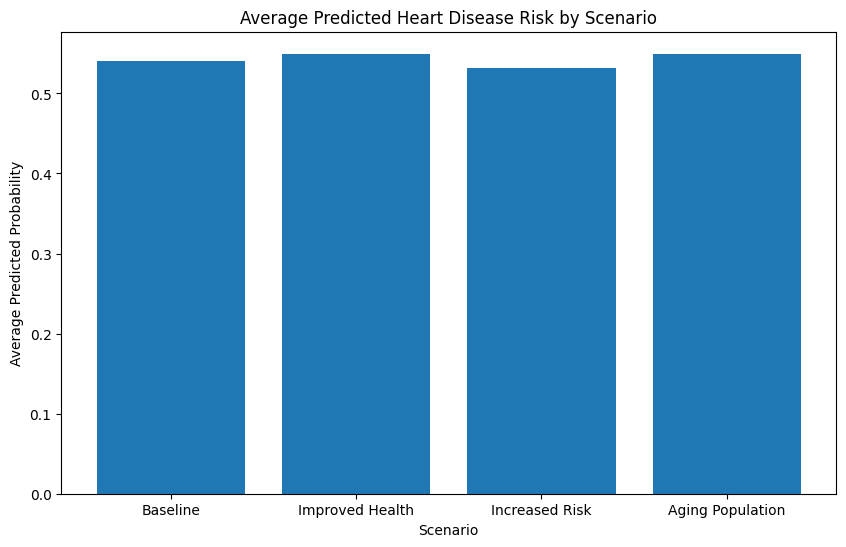

In [3]:
display(Markdown("### Scenario Comparison Visualization"))

plt.figure(figsize=(10,6))

plt.bar(
    results["Scenario"],
    results["Average_Heart_Disease_Risk"]
)

plt.title("Average Predicted Heart Disease Risk by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Average Predicted Probability")

plt.show()

### Sensitivity Analysis

,Adjustment_Factor,Average_Risk
0,0.9,0.547699
1,1.0,0.540253
2,1.1,0.533199
3,1.2,0.526587


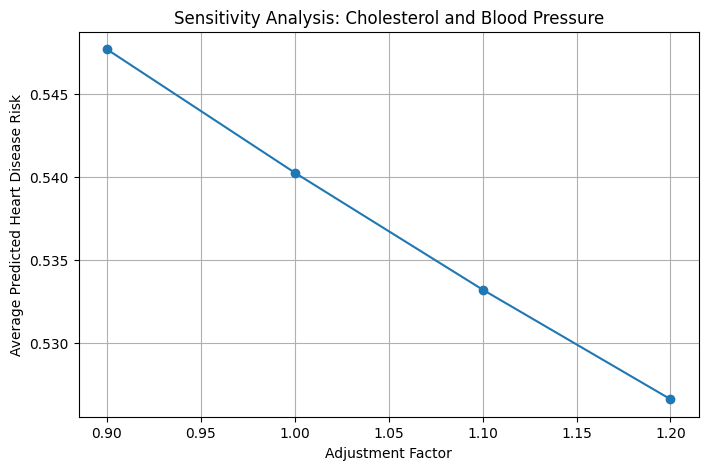

In [4]:
display(Markdown("### Sensitivity Analysis"))

sensitivity_results = []

for adjustment in [0.90, 1.00, 1.10, 1.20]:

    test_data = baseline_data.copy()

    for col in test_data.columns:

        if "chol" in col.lower():
            test_data[col] *= adjustment

        if "trestbps" in col.lower():
            test_data[col] *= adjustment

    test_scaled = scaler.transform(test_data)

    probabilities = optimized_svm.predict_proba(test_scaled)[:,1]

    sensitivity_results.append({
        "Adjustment_Factor": adjustment,
        "Average_Risk": probabilities.mean()
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

display(sensitivity_df)

plt.figure(figsize=(8,5))

plt.plot(
    sensitivity_df["Adjustment_Factor"],
    sensitivity_df["Average_Risk"],
    marker="o"
)

plt.title("Sensitivity Analysis: Cholesterol and Blood Pressure")
plt.xlabel("Adjustment Factor")
plt.ylabel("Average Predicted Heart Disease Risk")

plt.grid(True)
plt.show()

## Sensitivity and Impact Analysis

A sensitivity analysis was performed by modifying cholesterol and resting blood pressure values simultaneously. These features were selected because they are commonly associated with cardiovascular disease risk and are important factors in medical decision-making.

The results showed only small changes in the average predicted probability of heart disease as the feature values were adjusted. This suggests that the optimized SVM model may be relying on a combination of multiple variables rather than any single feature. It also indicates that the model is relatively stable when moderate changes are applied to cholesterol and blood pressure values.

From a real-world perspective, this finding highlights the complexity of heart disease prediction. While cholesterol and blood pressure remain important health indicators, accurate risk assessment typically requires evaluating multiple clinical factors together rather than focusing on a single measurement.
